In [1]:
import torch
from transformers import GPT2Model, GPT2Tokenizer
from transformers import BertModel, BertTokenizer
import matplotlib.pyplot as plt
import numpy as np
from torch.nn.functional import cosine_similarity

# GPT2
gpt2_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
gpt2_model = GPT2Model.from_pretrained("gpt2")
gpt2_model.eval()

# BERT
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model = BertModel.from_pretrained("bert-base-uncased")
bert_model.eval()

print("Ready!")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6000.09it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can

Ready!


In [2]:
words = ["king", "queen", "man", "woman", 
         "dog", "cat", "car", "truck", "happy", "sad"]

def get_gpt2_embedding(word):
    inputs = gpt2_tokenizer(word, return_tensors="pt")
    with torch.no_grad():
        outputs = gpt2_model(**inputs)
    return outputs.last_hidden_state[0].mean(dim=0)

def get_bert_embedding(word):
    inputs = bert_tokenizer(word, return_tensors="pt")
    with torch.no_grad():
        outputs = bert_model(**inputs)
    return outputs.last_hidden_state[0].mean(dim=0)

gpt2_embeddings = torch.stack([get_gpt2_embedding(w) for w in words])
bert_embeddings = torch.stack([get_bert_embedding(w) for w in words])

print("Embeddings ready!")
print(f"Shape: {gpt2_embeddings.shape}")

Embeddings ready!
Shape: torch.Size([10, 768])


In [3]:
n = len(words)

# Cosine similarity matrix
cosine_matrix = torch.zeros(n, n)
for i in range(n):
    for j in range(n):
        cosine_matrix[i, j] = cosine_similarity(
            gpt2_embeddings[i].unsqueeze(0),
            gpt2_embeddings[j].unsqueeze(0)
        ).item()

# Euclidean distance matrix
euclidean_matrix = torch.zeros(n, n)
for i in range(n):
    for j in range(n):
        euclidean_matrix[i, j] = torch.dist(
            gpt2_embeddings[i], 
            gpt2_embeddings[j]
        ).item()

print("Cosine Matrix (first 3 words):")
for i in range(3):
    for j in range(3):
        print(f"  {words[i]:8} vs {words[j]:8}: {cosine_matrix[i,j]:.4f}")

print("\nEuclidean Matrix (first 3 words):")
for i in range(3):
    for j in range(3):
        print(f"  {words[i]:8} vs {words[j]:8}: {euclidean_matrix[i,j]:.4f}")

Cosine Matrix (first 3 words):
  king     vs king    : 1.0000
  king     vs queen   : 0.9828
  king     vs man     : 0.9976
  queen    vs king    : 0.9828
  queen    vs queen   : 1.0000
  queen    vs man     : 0.9880
  man      vs king    : 0.9976
  man      vs queen   : 0.9880
  man      vs man     : 1.0000

Euclidean Matrix (first 3 words):
  king     vs king    : 0.0000
  king     vs queen   : 57.6786
  king     vs man     : 5.9422
  queen    vs king    : 57.6786
  queen    vs queen   : 0.0000
  queen    vs man     : 54.1036
  man      vs king    : 5.9422
  man      vs queen   : 54.1036
  man      vs man     : 0.0000


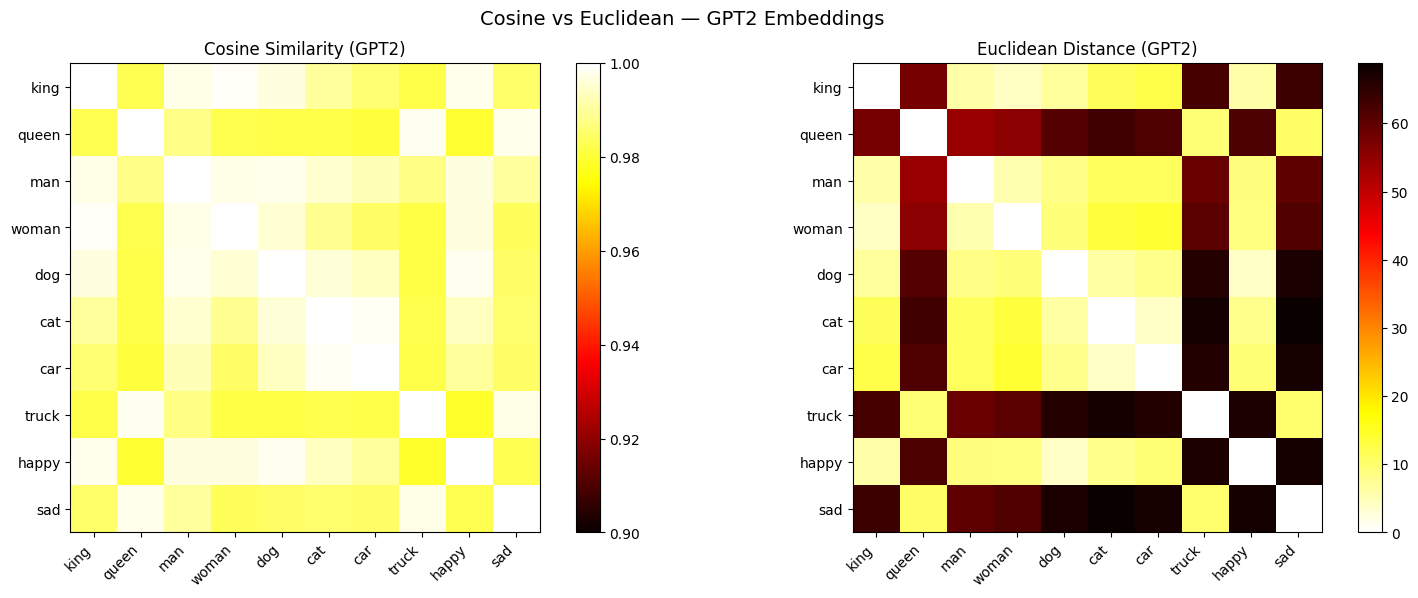

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Cosine heatmap
im1 = axes[0].imshow(cosine_matrix.numpy(), 
                      cmap="hot", vmin=0.9, vmax=1.0)
axes[0].set_xticks(range(n))
axes[0].set_yticks(range(n))
axes[0].set_xticklabels(words, rotation=45, ha="right")
axes[0].set_yticklabels(words)
axes[0].set_title("Cosine Similarity (GPT2)")
plt.colorbar(im1, ax=axes[0])

# Euclidean heatmap
im2 = axes[1].imshow(euclidean_matrix.numpy(), 
                      cmap="hot_r")
axes[1].set_xticks(range(n))
axes[1].set_yticks(range(n))
axes[1].set_xticklabels(words, rotation=45, ha="right")
axes[1].set_yticklabels(words)
axes[1].set_title("Euclidean Distance (GPT2)")
plt.colorbar(im2, ax=axes[1])

plt.suptitle("Cosine vs Euclidean — GPT2 Embeddings", fontsize=14)
plt.tight_layout()
plt.show()

* **Cosine similarity** (Cosine Similarity) measures the **direction** of vectors — which is why in models like GPT-2, many tokens appear **highly similar**.

* **Euclidean distance** (Euclidean Distance) measures the **actual distance between vectors**, revealing **more variation**.

* An interesting observation: *king–man* can be **closer in Euclidean space**, while *king–queen* may appear **farther**, which feels counterintuitive.

* Both metrics provide **different perspectives**, so using them together gives a **better understanding of token relationships**.
